<br>
<a href="https://github.com/aperture-systems-lab">
    <img src="assets/banner_semillero.png" width="955" style="margin: 0px 0px 12px;"/>
</a>
<h1 style="line-height: 1.4;"><font color="#29c4d9"><b>Cómo funcionan las redes neuronales</b></font></h1>
<h2><b>Notebook 4: </b>Tic-tac-toe</h2>

In [1]:
import random

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

import utils

torch.manual_seed(42)
random.seed(42)

----

<br>

## **Parte 0:** Nuestro objetivo

----

<br>

## **Parte 1:** El juego

In [2]:
EMPTY = (0,) * 9   # 9 casillas: 1 es de quien juega, -1 del rival, 0 está libre

LINES = [(0, 1, 2), (3, 4, 5), (6, 7, 8),    # filas
         (0, 3, 6), (1, 4, 7), (2, 5, 8),    # columnas
         (0, 4, 8), (2, 4, 6)]               # diagonales


def winner(board):
    for a, b, c in LINES:
        if board[a] != 0 and board[a] == board[b] == board[c]:
            return board[a]
    return 0


def free_cells(board):
    return [cell for cell, value in enumerate(board) if value == 0]


def play_at(board, cell):
    next_board = list(board)
    next_board[cell] = 1
    return tuple(-value for value in next_board)   # el turno pasa al rival

In [3]:
def show(board):
    marks = {1: "X", -1: "O", 0: "·"}
    for row in range(3):
        print(" ".join(marks[board[row * 3 + column]] for column in range(3)))


board = play_at(play_at(play_at(EMPTY, 4), 0), 8)

show(board)
print("\nlibres:", free_cells(board), "| ganador:", winner(board))

X · ·
· O ·
· · O

libres: [1, 2, 3, 5, 6, 7] | ganador: 0


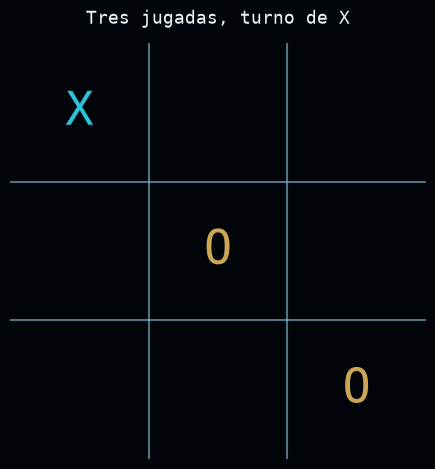

In [4]:
utils.dibujar_tablero(board, titulo="Tres jugadas, turno de X")

----

<br>

## **Parte 2:** El rival perfecto

In [5]:
cache = {}


def minimax(board):
    if board in cache:
        return cache[board]

    if winner(board) == -1:             # el rival acaba de ganar
        result = (-1, [])
    elif not free_cells(board):         # no queda dónde jugar
        result = (0, [])
    else:
        values = {cell: -minimax(play_at(board, cell))[0] for cell in free_cells(board)}
        best = max(values.values())
        result = (best, [cell for cell, value in values.items() if value == best])

    cache[board] = result
    return result


value, best_moves = minimax(EMPTY)
print("tablero vacío -> valor:", value, "| jugadas óptimas:", best_moves)

threat = (-1, -1, 0,
           0,  1, 0,
           0,  0, 0)
print("hay que bloquear ->", minimax(threat))

tablero vacío -> valor: 0 | jugadas óptimas: [0, 1, 2, 3, 4, 5, 6, 7, 8]
hay que bloquear -> (0, [2])


----

<br>

## **Parte 3:** Los datos

In [6]:
table = pd.read_csv("datos/tictactoe.csv")   # cada fila es un tablero y su mejor jugada

print("posiciones:", table.shape)
table.head()

posiciones: (4520, 10)


,c0,c1,c2,c3,c4,c5,c6,c7,c8,best
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,-1,4
2,0,0,0,0,0,0,0,-1,1,2
3,0,0,0,0,0,0,-1,1,-1,4
4,0,0,0,0,0,-1,1,-1,1,0


In [7]:
board_columns = [f"c{i}" for i in range(9)]

X = torch.tensor(table[board_columns].to_numpy(dtype="float32"))
y = torch.tensor(table["best"].to_numpy(), dtype=torch.long)

boards = [tuple(int(value) for value in row) for row in table[board_columns].to_numpy()]

print("X:", tuple(X.shape), X.dtype, " <- las 9 casillas")
print("y:", tuple(y.shape), y.dtype, " <- la casilla donde hay que jugar")
print("veces que se usa cada casilla:", torch.bincount(y).tolist())

X: (4520, 9) torch.float32  <- las 9 casillas
y: (4520,) torch.int64  <- la casilla donde hay que jugar
veces que se usa cada casilla: [1081, 587, 676, 365, 713, 244, 365, 171, 318]


In [8]:
example = boards[17]

show(example)
print("\njugadas óptimas:", minimax(example)[1], "| etiqueta:", int(y[17]))

· X ·
O O X
O X O

jugadas óptimas: [0, 2] | etiqueta: 0


In [9]:
order = torch.randperm(len(X))
split = int(0.8 * len(X))

x_train, y_train = X[order[:split]], y[order[:split]]
x_test, y_test = X[order[split:]], y[order[split:]]

test_boards = [boards[i] for i in order[split:].tolist()]

print("entrenar:", tuple(x_train.shape), "| probar:", tuple(x_test.shape))

entrenar: (3616, 9) | probar: (904, 9)


----

<br>

## **Parte 4:** La red

In [10]:
class Player(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.layer_1 = nn.Linear(9, hidden)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(hidden, hidden)
        self.layer_3 = nn.Linear(hidden, 9)   # un puntaje por casilla

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)
        return x

In [11]:
@torch.no_grad()
def accuracy(model, x, y):
    return (model(x).argmax(dim=1) == y).float().mean().item()


@torch.no_grad()
def choose(model, board):
    scores = model(torch.tensor([list(board)], dtype=torch.float32))[0]
    scores[[cell for cell in range(9) if board[cell] != 0]] = float("-inf")
    return int(scores.argmax())

In [12]:
torch.manual_seed(42)

model = Player()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = {"entrenamiento": [], "prueba": []}
accuracies = {"entrenamiento": [], "prueba": []}

for epoch in range(600):
    optimizer.zero_grad()                         # 1. borrar los gradientes viejos
    scores = model(x_train)                       # 2. predecir
    loss = loss_function(scores, y_train)         # 3. medir el error
    loss.backward()                               # 4. calcular gradientes
    optimizer.step()                              # 5. actualizar parametros

    with torch.no_grad():
        test_loss = loss_function(model(x_test), y_test)

    losses["entrenamiento"].append(loss.item())
    losses["prueba"].append(test_loss.item())
    accuracies["entrenamiento"].append(accuracy(model, x_train, y_train))
    accuracies["prueba"].append(accuracy(model, x_test, y_test))

    if (epoch + 1) % 100 == 0:
        print(f"Época {epoch + 1:4d} — pérdida: {loss.item():.4f}"
              f" — exactitud en prueba: {accuracies['prueba'][-1]:.3f}")

Época  100 — pérdida: 0.0868 — exactitud en prueba: 0.819
Época  200 — pérdida: 0.0131 — exactitud en prueba: 0.825
Época  300 — pérdida: 0.0044 — exactitud en prueba: 0.826
Época  400 — pérdida: 0.0022 — exactitud en prueba: 0.825
Época  500 — pérdida: 0.0013 — exactitud en prueba: 0.826
Época  600 — pérdida: 0.0009 — exactitud en prueba: 0.825


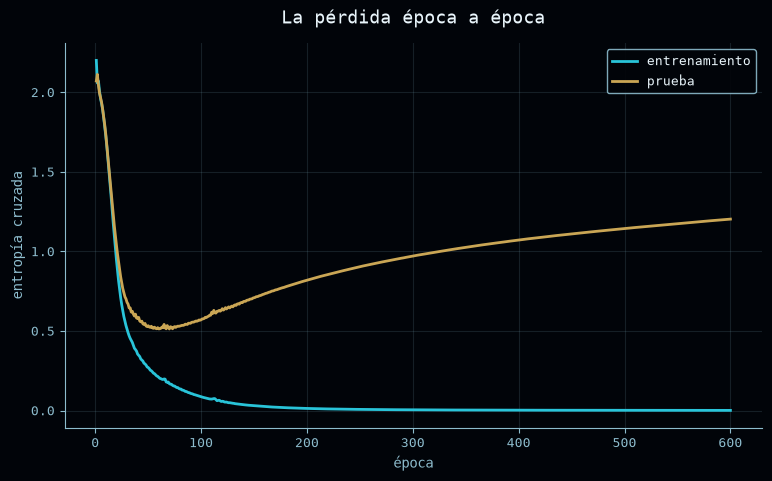

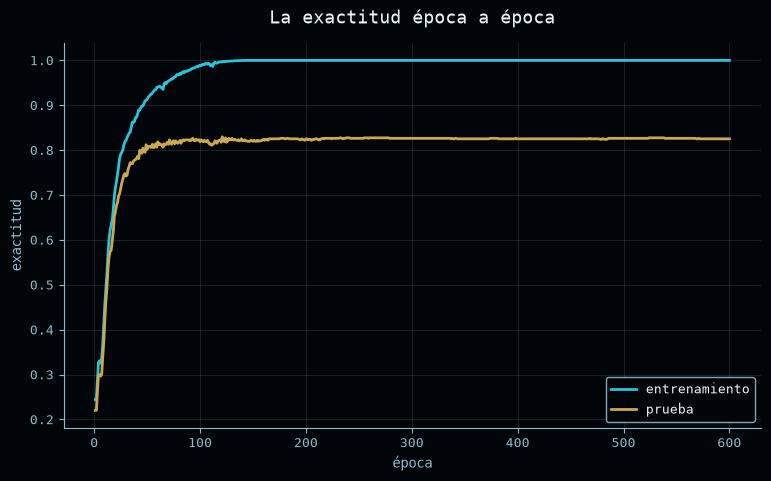

In [13]:
utils.dibujar_metricas(losses, titulo="La pérdida época a época", y_etiqueta="entropía cruzada")
utils.dibujar_metricas(accuracies, titulo="La exactitud época a época", y_etiqueta="exactitud")

----

<br>

## **Parte 5:** Qué aprendió

In [14]:
optimal = sum(choose(model, board) in minimax(board)[1] for board in test_boards)

print(f"acierta la etiqueta : {accuracy(model, x_test, y_test):.3f}")
print(f"juega una óptima    : {optimal / len(test_boards):.3f}")

acierta la etiqueta : 0.825
juega una óptima    : 0.936


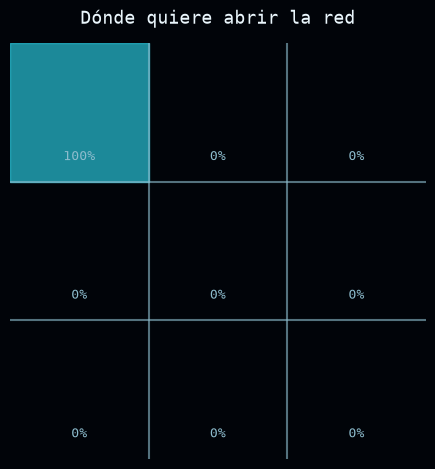

In [15]:
@torch.no_grad()
def preferences(model, board):
    scores = model(torch.tensor([list(board)], dtype=torch.float32))[0]
    scores[[cell for cell in range(9) if board[cell] != 0]] = float("-inf")
    return torch.softmax(scores, dim=0)


utils.dibujar_tablero(EMPTY, preferences(model, EMPTY), titulo="Dónde quiere abrir la red")

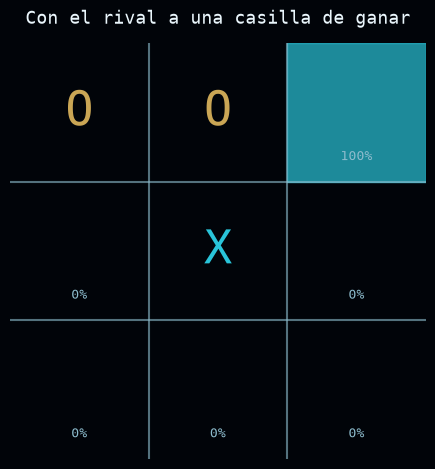

jugadas óptimas: [2] | la red juega: 2


In [16]:
utils.dibujar_tablero(threat, preferences(model, threat),
                      titulo="Con el rival a una casilla de ganar")

print("jugadas óptimas:", minimax(threat)[1], "| la red juega:", choose(model, threat))

----

<br>

## **Parte 6:** A jugar

In [17]:
def play_game(opponent, network_starts=True, narrate=False):
    board = EMPTY
    network_turn = network_starts

    while True:
        if winner(board) == -1:
            return -1 if network_turn else 1      # ganó quien acaba de jugar
        if not free_cells(board):
            return 0

        cell = choose(model, board) if network_turn else opponent(board)
        board = play_at(board, cell)
        network_turn = not network_turn

        if narrate:
            print(f"{'red' if not network_turn else 'rival'} juega en {cell}")
            show(board if network_turn else tuple(-value for value in board))
            print()


random_move = lambda board: random.choice(free_cells(board))
perfect_move = lambda board: min(minimax(board)[1])

In [18]:
results = [play_game(random_move, network_starts=(i % 2 == 0)) for i in range(200)]

print("contra un rival al azar, en 200 partidas")
print("  gana  :", results.count(1))
print("  empata:", results.count(0))
print("  pierde:", results.count(-1))

contra un rival al azar, en 200 partidas
  gana  : 184
  empata: 15
  pierde: 1


In [19]:
print("la red empieza :", play_game(perfect_move, network_starts=True))
print("empieza minimax:", play_game(perfect_move, network_starts=False))

la red empieza : 0
empieza minimax: -1


In [20]:
play_game(perfect_move, network_starts=True, narrate=True)

red juega en 0
X · ·
· · ·
· · ·

rival juega en 4
X · ·
· O ·
· · ·

red juega en 1
X X ·
· O ·
· · ·

rival juega en 2
X X O
· O ·
· · ·

red juega en 6
X X O
· O ·
X · ·

rival juega en 3
X X O
O O ·
X · ·

red juega en 5
X X O
O O X
X · ·

rival juega en 7
X X O
O O X
X O ·

red juega en 8
X X O
O O X
X O X



0

In [21]:
def play_against_network():
    board = EMPTY
    show(board)

    while True:
        cell = int(input("\ntu casilla (0 a 8): "))
        if cell not in free_cells(board):
            print("esa no se puede")
            continue

        board = play_at(board, cell)
        if winner(board) == -1:
            show(tuple(-value for value in board))
            return print("\nganaste")
        if not free_cells(board):
            return print("\nempate")

        board = play_at(board, choose(model, board))
        show(board)   # siempre desde tu lado: tú eres X
        if winner(board) == -1:
            return print("\ngana la red")
        if not free_cells(board):
            return print("\nempate")

In [22]:
play_against_network()

· · ·
· · ·
· · ·
· · ·
· O ·
· · X
O X ·
· O ·
· · X
O X X
· O O
· · X
O X X
X O O
O · X
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede
esa no se puede

empate


----

<br>

## **Cierre**

-----

<br>

### <font color="#29c4d9">**Notebook 4 listo.**</font>

<br>

---

<div style="margin-top: 50px;"><center><a href="https://github.com/aperture-systems-lab"><img src="assets/banner_logo.png" width="955"/></a></center></div>